# Up, down, and control geo lift with PyMC

A geo lift test can assign two active arms: increase media spend in some geos (up), decrease it in others (down), and leave control geos unchanged. The up and down arms probe the revenue response on opposite sides of business-as-usual spend. We estimate each treated geo's signed revenue effect relative to its own business-as-usual path, rather than subtracting the down arm from the up arm.

The workflow has four stages:

1. Plan the geo assignments, spend changes, and test duration. We assume those decisions have already been made; experimental design is outside this example.
2. Run the intervention and record delivered spend and revenue. Here we simulate that real-world step, so the no-intervention outcomes and true effects in this simulated world are known.
3. Fit a synthetic-control counterfactual from the unchanged geos, inspect its fit, and estimate the up and down effects with `UpDownGeoLift`.
4. Export geo-level lift observations for a geo-varying PyMC-Marketing MMM. A future PyMC-Marketing documentation page will show the calibration step.

The key assumptions are that the intervention does not spill over into control geos, the pre-intervention relationship between treated and control geos remains useful afterward, and no other change at the intervention date differs systematically by arm. Assignment labels record the intended direction; delivered spend defines the intervention actually analyzed.

## Simulate assignment and delivered spend

The simulated panel is weekly and has two media channels, `search` and `display`. This particular experiment changes `search` while `display` remains unchanged. Up and down geos have different saturation parameters, so their true effects in the simulated world vary by geo. Planned spend changes offset in total, while delivered changes are smaller because delivery is 90% of plan.

In [1]:
%config InlineBackend.figure_format = 'retina'

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import StrMethodFormatter

import causalpy as cp
from causalpy.data.simulate_data import generate_up_down_geolift_data

FIG_WIDTH = 8
FIG_HEIGHT = 4.5
COLOR_UP = "#237A65"
COLOR_DOWN = "#B55A45"
COLOR_CONTROL = "#456A9A"

simulated = generate_up_down_geolift_data(seed=415, n_pre=32, n_post=8, n_control=5)
simulated.arms

{'up': ['up_1', 'up_2'],
 'down': ['down_1', 'down_2'],
 'control': ['control_1', 'control_2', 'control_3', 'control_4', 'control_5']}

The `arms` mapping records assignment. The `spend_planned` and `spend_realized` panels record intended and delivered spend; `spend_baseline` is the business-as-usual path. The simulator also exposes the no-intervention revenue and treatment effects, which would be unobserved in a real experiment.

**Caption:** Arm-average weekly search spend (top) and revenue (bottom), in USD per week. Solid lines show delivered spend or observed revenue; dashed lines show business-as-usual spend or no-intervention revenue, which is known here because the data are simulated. The black vertical line marks the first intervention week.

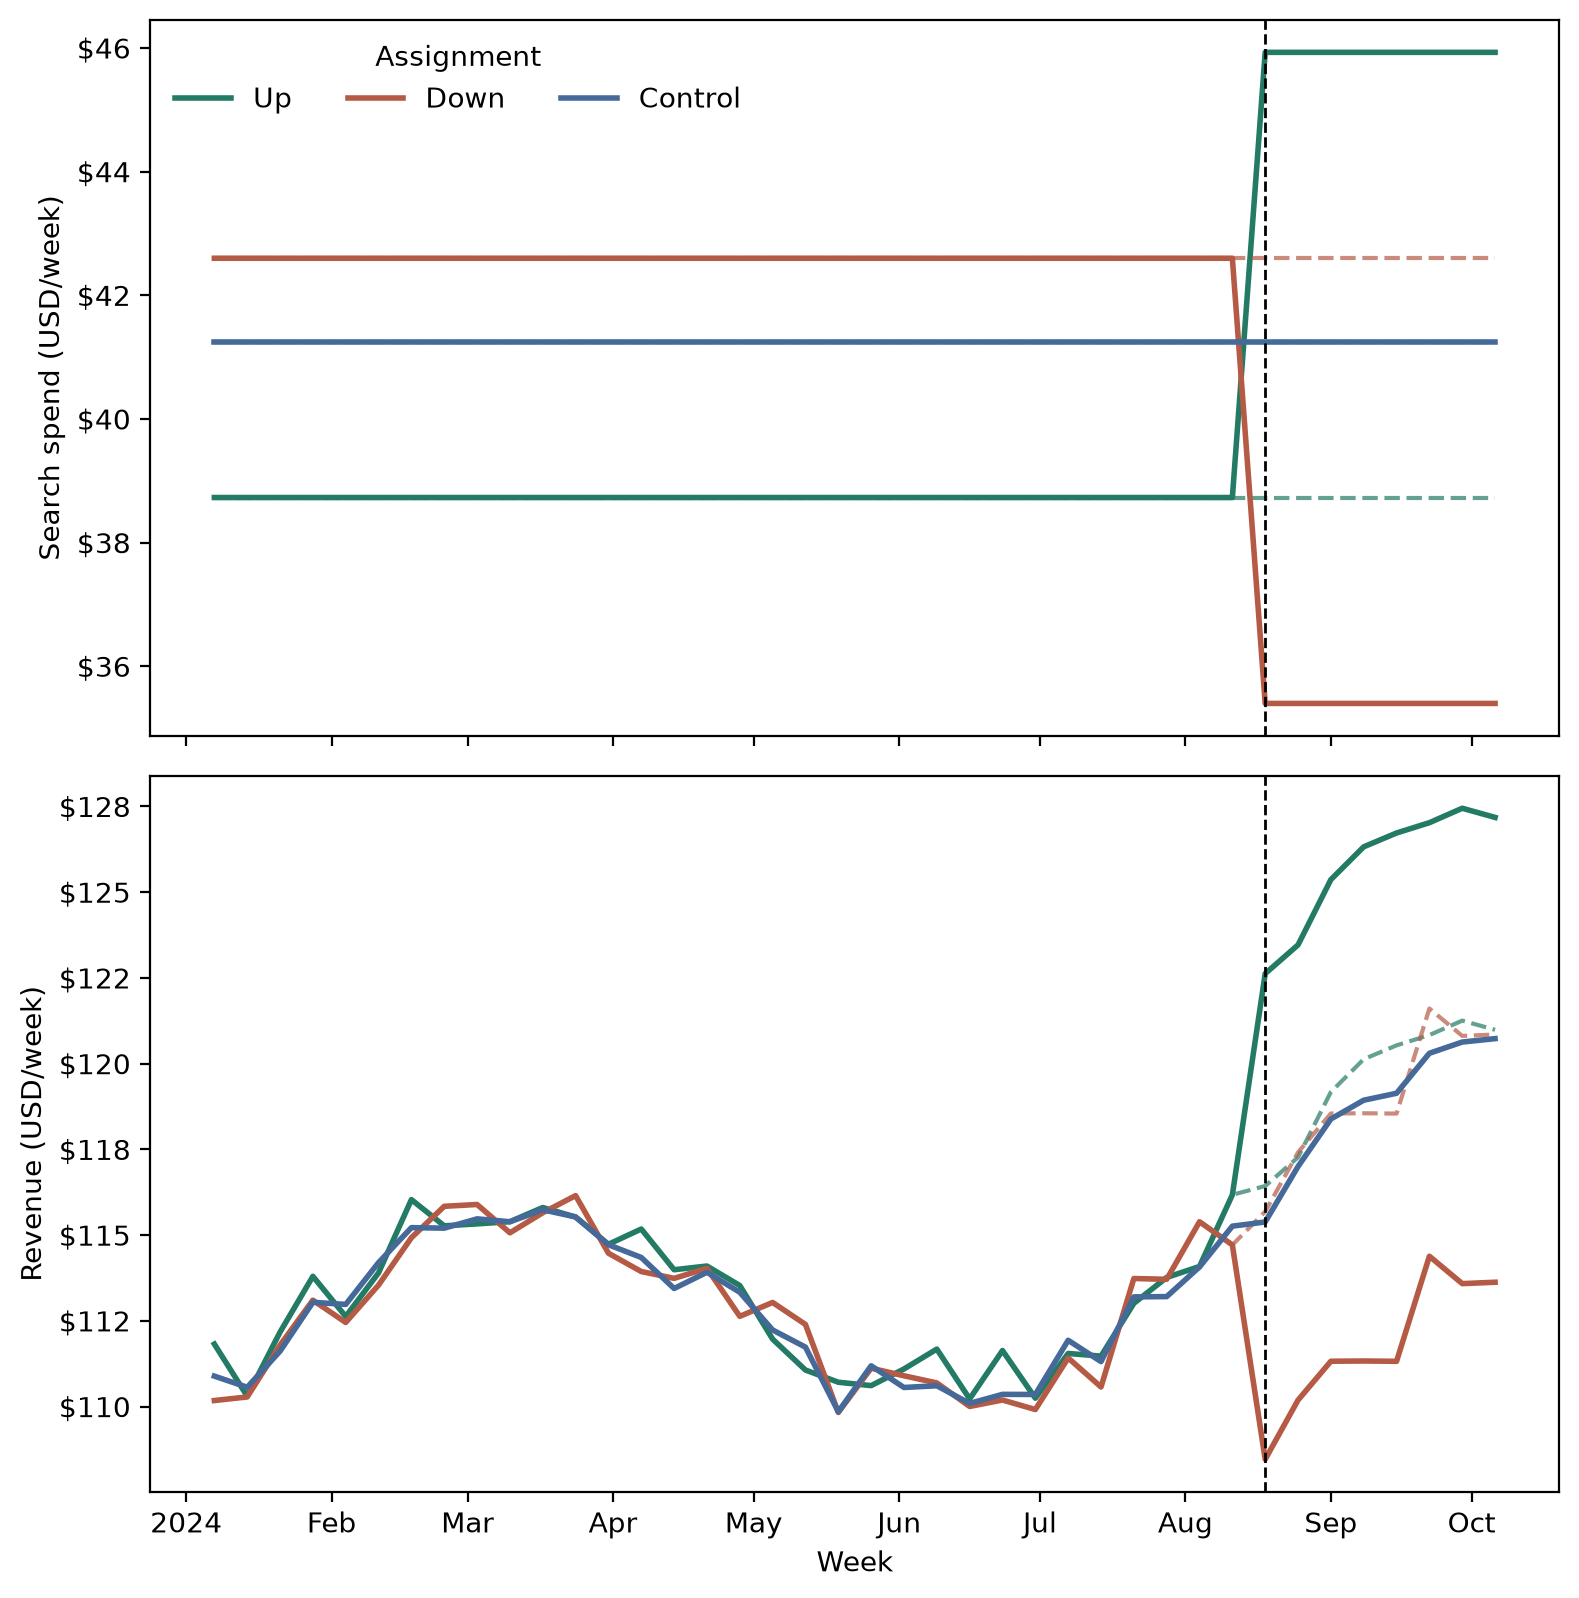

In [2]:
baseline_search = simulated.spend_baseline.xs("search", axis=1, level="channel")
realized_search = simulated.spend_realized.xs("search", axis=1, level="channel")
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(FIG_WIDTH, FIG_HEIGHT * 1.8))
for arm, color in (("up", COLOR_UP), ("down", COLOR_DOWN), ("control", COLOR_CONTROL)):
    geos = simulated.arms[arm]
    axes[0].plot(
        baseline_search.index,
        baseline_search[geos].mean(axis=1),
        color=color,
        linestyle="--",
        alpha=0.7,
    )
    axes[0].plot(
        realized_search.index,
        realized_search[geos].mean(axis=1),
        color=color,
        linewidth=2,
        label=arm.title(),
    )
    axes[1].plot(
        simulated.no_intervention.index,
        simulated.no_intervention[geos].mean(axis=1),
        color=color,
        linestyle="--",
        alpha=0.7,
    )
    axes[1].plot(
        simulated.revenue.index,
        simulated.revenue[geos].mean(axis=1),
        color=color,
        linewidth=2,
    )
for ax in axes:
    ax.axvline(simulated.treatment_time, color="black", linestyle="--", linewidth=1)
    ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
axes[0].set_ylabel("Search spend (USD/week)")
axes[1].set_ylabel("Revenue (USD/week)")
axes[1].set_xlabel("Week")
axes[0].legend(title="Assignment", ncol=3, frameon=False)
locator = mdates.AutoDateLocator()
axes[1].xaxis.set_major_locator(locator)
axes[1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
fig.tight_layout()
plt.show()

Before the intervention, the delivered and business-as-usual paths coincide. Afterward, search spend rises for the up geos, falls for the down geos, and stays unchanged for controls; the revenue panel shows the corresponding observed and no-intervention paths. The no-intervention lines are a simulation-only reference, not information available to the estimator.

## Synthetic control and the up/down extension

{term}`Synthetic control` builds a weighted combination of unchanged control geos (the donor pool) to track each treated geo before the intervention. After the intervention, the same weights applied to the controls estimate what the treated geo's revenue would have been without its spend change. Observed revenue minus this counterfactual is the signed effect. A close pre-intervention fit supports the comparison, but it cannot by itself rule out spillovers or a concurrent geo-specific shock. For a single-treated-unit introduction, see {doc}`synthetic-control-pymc`.

`UpDownGeoLift` uses the same `SyntheticControl` counterfactual machinery. It asks for explicit, disjoint `up`, `down`, and `control` assignments, uses only control geos as donors, and fits the treated geos together so their posterior draws stay aligned. It retains each treated geo's weekly effect and summarizes the up and down arms separately within each draw. Its inherited three-panel plot lets us inspect the observed and synthetic trajectories, weekly impact, and cumulative impact for any treated geo.

## Fit the counterfactual

For each treated geo and post-intervention week, the estimand is observed revenue under delivered spend minus revenue under its business-as-usual spend path. `UpDownGeoLift` estimates the second term from unchanged controls; down geos are treated units, never donors. We use Bayesian nonnegative weights that sum to one and retain the aligned `chain` and `draw` coordinates across geos.

In [3]:
model = cp.pymc_models.SoftmaxWeightedSumFitter(
    sample_kwargs={
        "draws": 500,
        "tune": 500,
        "chains": 2,
        "cores": 2,
        "target_accept": 0.95,
        "random_seed": 415,
        "progressbar": False,
    }
)
result = cp.UpDownGeoLift(
    simulated.revenue,
    treatment_time=simulated.treatment_time,
    arms=simulated.arms,
    model=model,
).fit()

## Inspect the counterfactual fit

Use the inherited `plot()` method for a representative geo from each active arm. The top panel compares observed revenue with the fitted pre-intervention trajectory and post-intervention counterfactual. The middle and bottom panels show weekly and cumulative impact. Check the pre-intervention fit and the width of the uncertainty bands before interpreting an effect or exporting it for calibration.

**Caption:** Synthetic-control diagnostics for one up geo. Observed and counterfactual revenue (top) and weekly impact (middle) are in USD per week; cumulative impact (bottom) is in USD. Bands are 94% posterior intervals, and the vertical line marks the intervention.

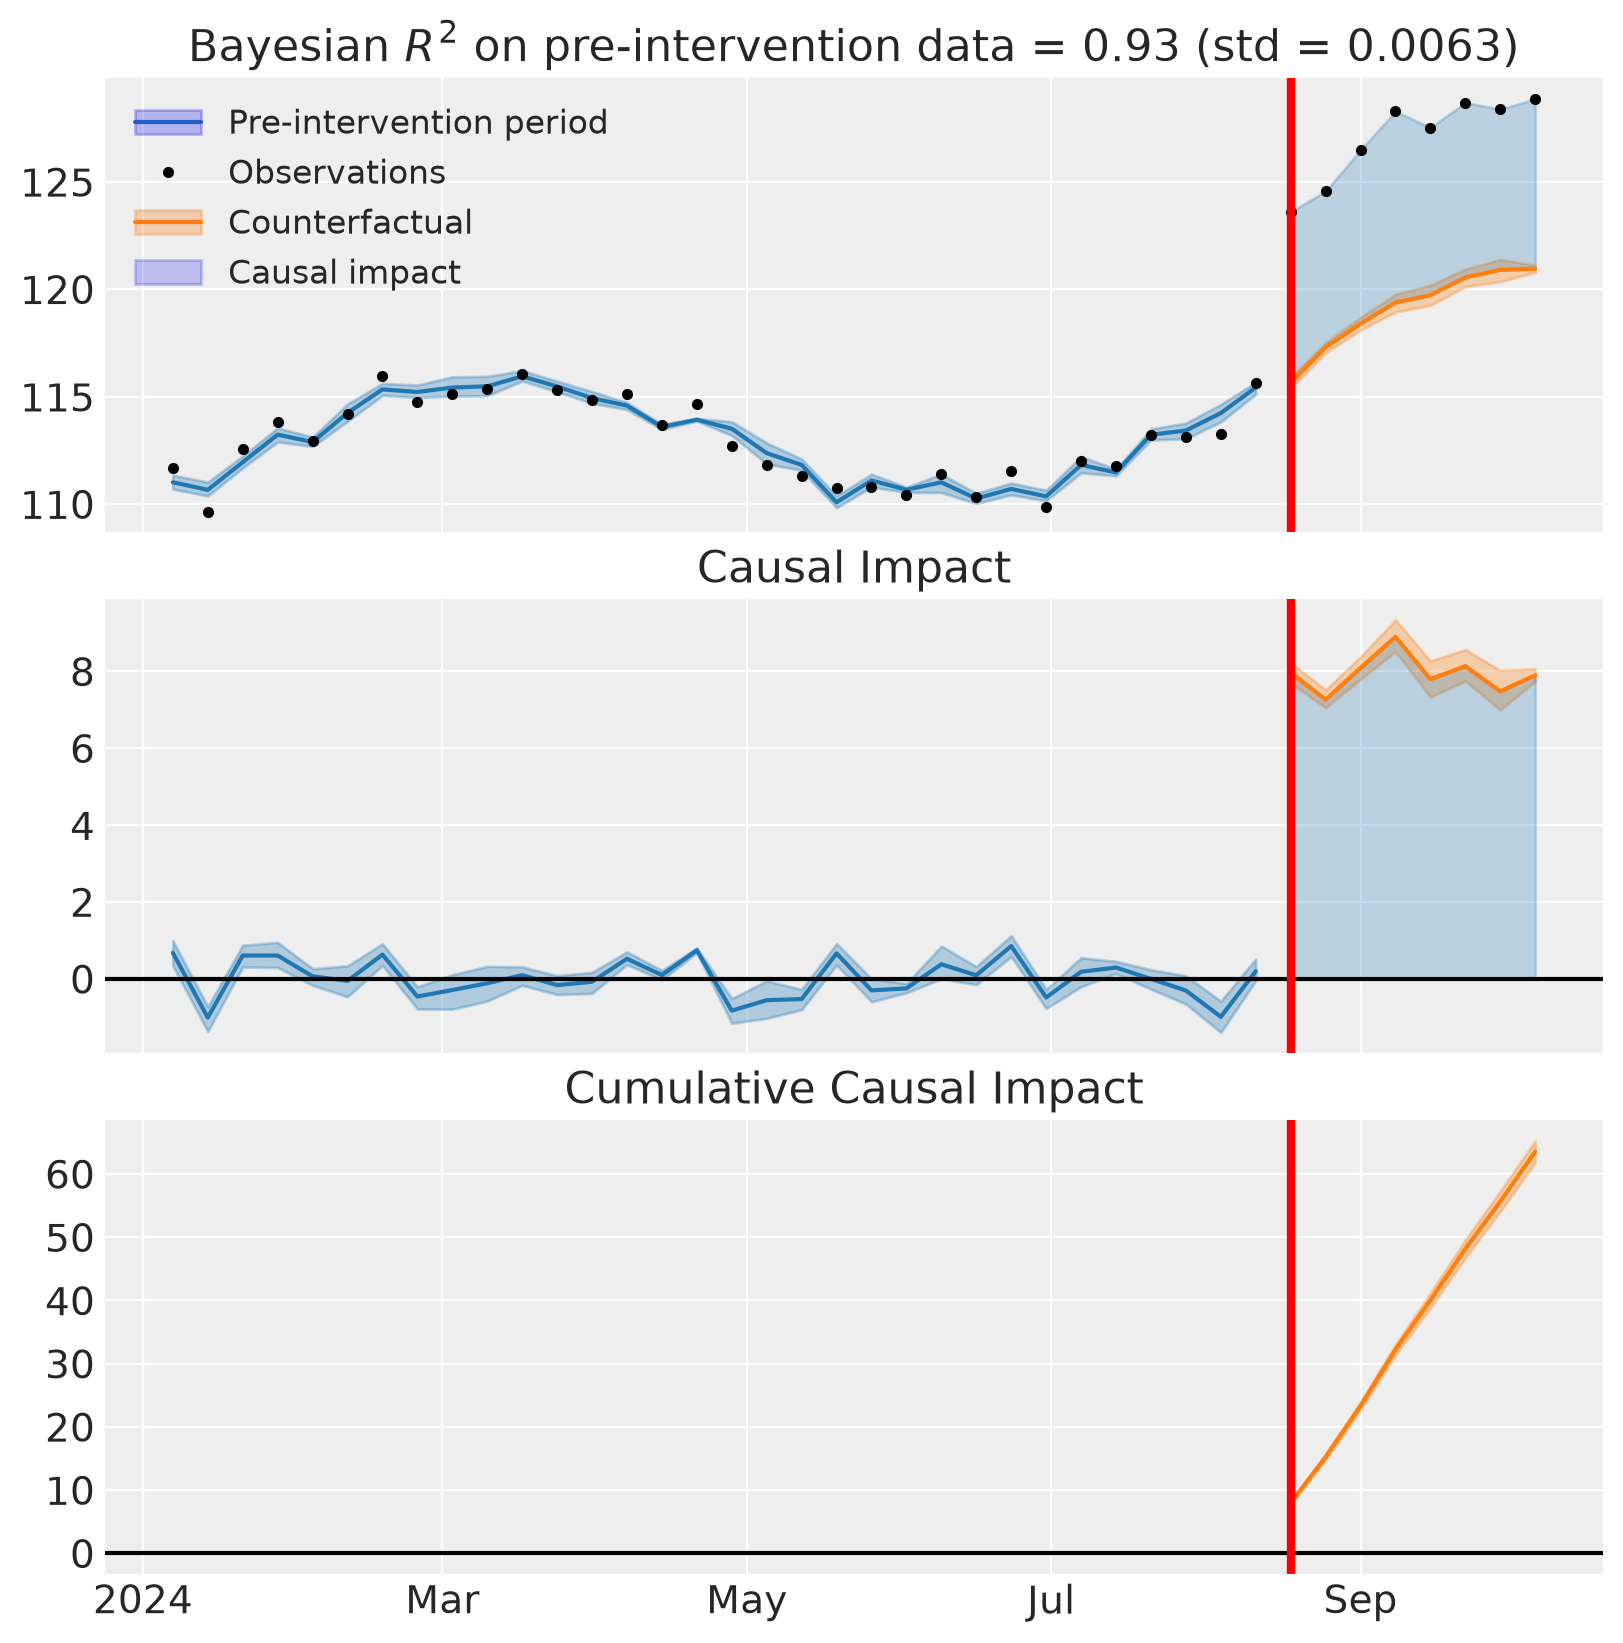

In [4]:
result.plot(
    treated_unit=simulated.arms["up"][0], figsize=(FIG_WIDTH, FIG_HEIGHT * 1.8)
);

**Caption:** The same three synthetic-control diagnostics for one down geo, with weekly revenue and impact in USD per week and cumulative impact in USD. Post-intervention impacts retain their negative sign.

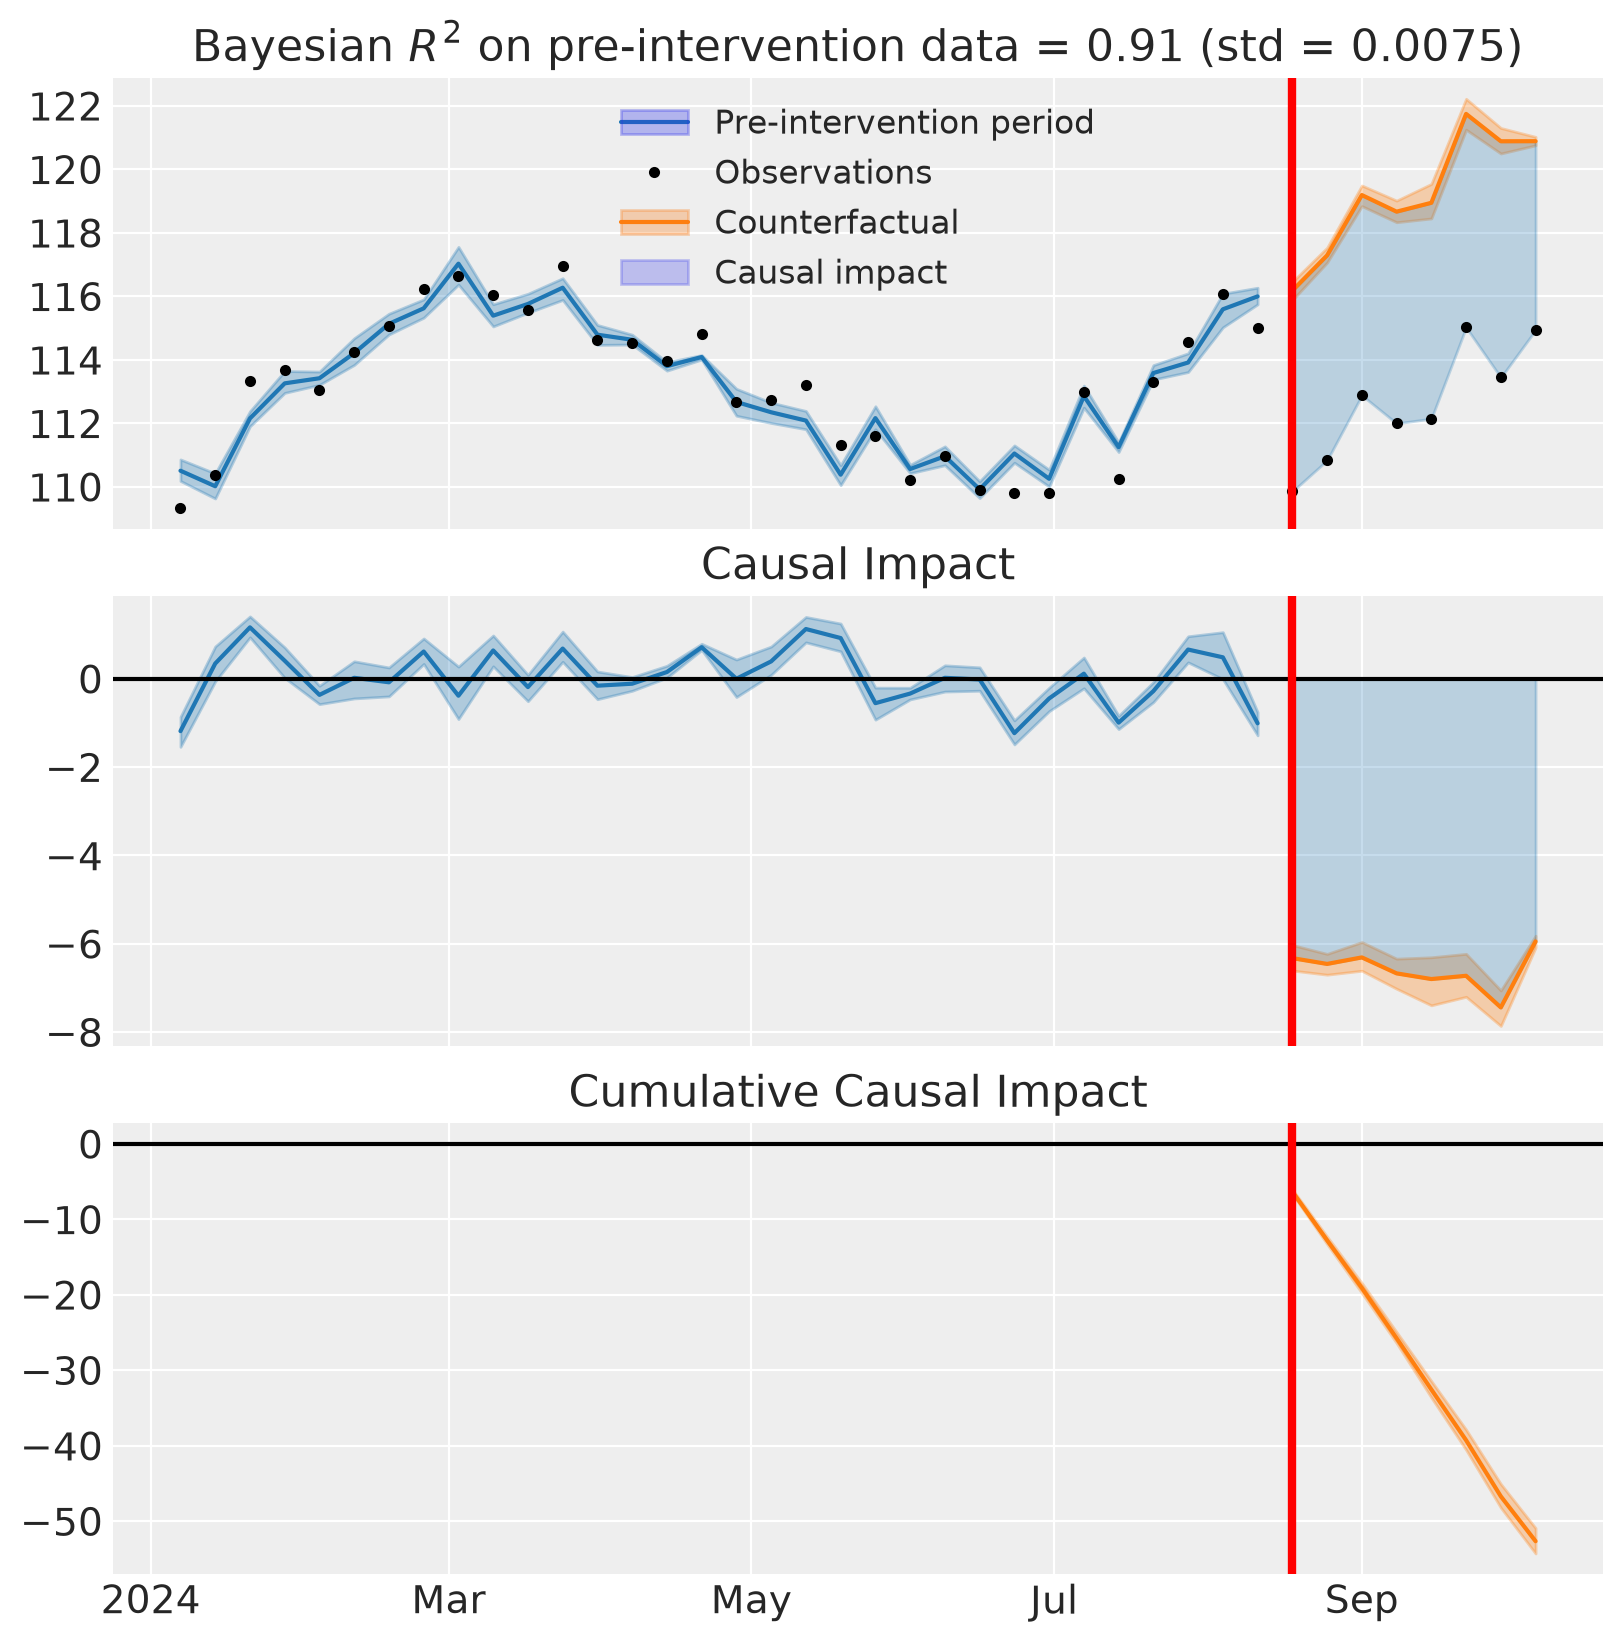

In [5]:
result.plot(
    treated_unit=simulated.arms["down"][0], figsize=(FIG_WIDTH, FIG_HEIGHT * 1.8)
);

In these representative geos, the pre-intervention fit is the first check on whether the controls can reproduce the treated series. After the intervention, the estimated counterfactual separates from observed revenue in opposite directions for up and down geos. These plots do not prove the no-spillover or no-concurrent-shock assumptions; those still require design knowledge. Inspect the remaining treated geos with `result.plot(treated_unit=...)` before using all of their lift rows.

## Summarize signed geo and arm effects

The table keeps every treated geo and the two active arms separate. Arm means are computed from the same posterior draw across geos, so the uncertainty reflects their joint fit.

In [6]:
result.arm_effect_table()

,level,geo,arm,mean,sd,lower_94,upper_94,window_start,window_end,n_periods,aggregate
0,geo,up_1,up,7.941863,0.116785,7.744437,8.180999,2024-08-18 00:00:00,2024-10-06 00:00:00,8,mean
1,geo,up_2,up,5.219866,0.128969,4.999669,5.492156,2024-08-18 00:00:00,2024-10-06 00:00:00,8,mean
2,geo,down_1,down,-6.582396,0.117070,-6.772135,-6.326163,2024-08-18 00:00:00,2024-10-06 00:00:00,8,mean
3,geo,down_2,down,-7.662481,0.163907,-7.935871,-7.328037,2024-08-18 00:00:00,2024-10-06 00:00:00,8,mean
4,arm,NaN,up,6.580865,0.087179,6.432323,6.758744,2024-08-18 00:00:00,2024-10-06 00:00:00,8,mean
5,arm,NaN,down,-7.122438,0.100121,-7.298190,-6.925361,2024-08-18 00:00:00,2024-10-06 00:00:00,8,mean


The table reports a signed mean effect per week for each treated geo and a separate mean for each arm. The 94% intervals summarize posterior draws after averaging geos within each draw, preserving the dependence among geo estimates. A cumulative effect is available with `aggregate="sum"`. The constructor warns that a few pre-intervention treated observations lie outside the donor convex hull; inspect this {term}`Convex hull condition` alongside the fit plots before treating the intervals as complete uncertainty about the counterfactual.

## Check recovery against known simulated effects

Because we simulated the data, we know each geo's no-intervention potential outcome and the effect of its delivered spend change. This parameter-recovery check compares the true mean weekly effect in this simulated world with the posterior estimate over the same eight-week window.

**Caption:** Posterior mean weekly revenue effect and 94% equal-tailed interval by treated geo; open circles mark the known simulation truth. Colors identify assignment arms.

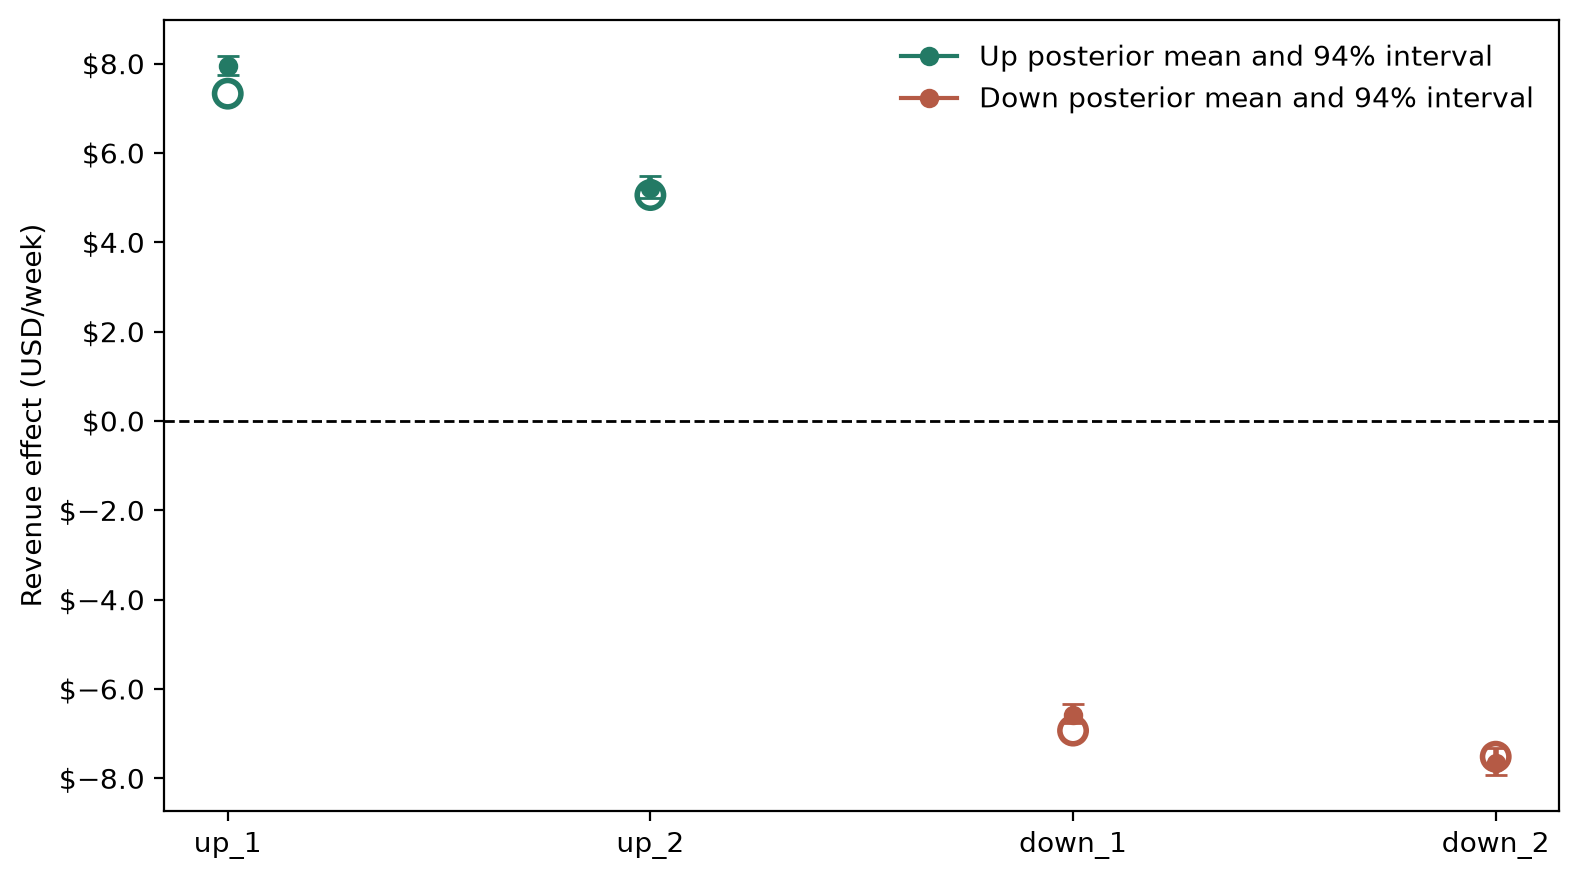

In [7]:
table = result.arm_effect_table()
geo_table = table.loc[table["level"] == "geo"].set_index("geo")
truth = simulated.effects.loc[simulated.treatment_time :].mean()
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
for position, geo in enumerate(result.treated_units):
    row = geo_table.loc[geo]
    color = COLOR_UP if row["arm"] == "up" else COLOR_DOWN
    ax.errorbar(
        position,
        row["mean"],
        yerr=[[row["mean"] - row["lower_94"]], [row["upper_94"] - row["mean"]]],
        fmt="o",
        color=color,
        capsize=4,
        linewidth=2,
        zorder=3,
    )
    ax.scatter(
        position,
        truth[geo],
        facecolors="none",
        edgecolors=color,
        s=90,
        linewidths=2,
        zorder=4,
    )
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_xticks(range(len(result.treated_units)), result.treated_units)
ax.set_ylabel("Revenue effect (USD/week)")
ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.1f}"))
ax.legend(
    handles=[
        Line2D(
            [0],
            [0],
            color=COLOR_UP,
            marker="o",
            label="Up posterior mean and 94% interval",
        ),
        Line2D(
            [0],
            [0],
            color=COLOR_DOWN,
            marker="o",
            label="Down posterior mean and 94% interval",
        ),
    ],
    frameon=False,
    loc="best",
)
fig.tight_layout()
plt.show()

The estimated effects have the correct signs, but the known simulated effect falls outside some 94% intervals. This is a limit of the recovery in this run, not evidence that the true effect is unknown here: the simulator gives us that truth. The donor model's posterior interval does not include every source of counterfactual error in the simulated panel. Inspect pre-intervention fit and posterior diagnostics before using a row for calibration.

## Build scalar MMM calibration rows

For the selected complete weekly window, `x` is mean business-as-usual search spend per week, `delta_x` is mean realized minus business-as-usual search spend per week, and `delta_y` is mean signed revenue effect per week. `sigma` is the posterior standard deviation of that mean effect. The revenue and both spend panels carry `attrs["unit"] = "USD/week"`, which the exporter checks against the declared units. Both spend panels must contain every selected outcome week. Baseline spend and delivered change must remain stable across the window; otherwise a nonlinear saturation response at mean spend is not the mean response to a changing spend path. The exported rows retain arm, window, period count, and unit metadata; PyMC-Marketing uses the scalar likelihood columns plus `geo` when geo is an MMM dimension.

In [8]:
lift_rows = result.to_mmm_lift(
    spend_baseline=simulated.spend_baseline,
    spend_realized=simulated.spend_realized,
    channel=simulated.tested_channel,
    spend_unit="USD/week",
    outcome_unit="USD/week",
    start=simulated.treatment_time,
    end=simulated.revenue.index[-1],
)
lift_rows[["channel", "geo", "arm", "x", "delta_x", "delta_y", "sigma", "n_periods"]]

,channel,geo,arm,x,delta_x,delta_y,sigma,n_periods
0,search,up_1,up,32.485767,7.2,7.941863,0.116785,8
1,search,up_2,up,44.973953,7.2,5.219866,0.128969,8
2,search,down_1,down,45.138887,-7.2,-6.582396,0.117070,8
3,search,down_2,down,40.060672,-7.2,-7.662481,0.163907,8


The rows are marginal summaries for a scalar lift likelihood. The joint posterior remains available as `result.impact_draws` or through `result.aggregate_draws()`. A downstream model that needs cross-geo covariance should use those draws instead of treating the rows as independent. The simple simulator has no carryover; if an experiment has delayed effects, verify that the chosen stable response window and spend definition match the MMM's adstock convention before exporting.

:::{note}
**TODO: PyMC-Marketing calibration walkthrough.** Link here to a PyMC-Marketing documentation page showing how to pass these geo-level lift rows into a geo-varying MMM when that page is available. This CausalPy example stops at the export contract.
:::

## Summary

- Keep up and down effects signed and summarize the two active arms separately.
- Inspect donor-based counterfactual fit before interpreting effects.
- Compare estimates with the known effects when the data are simulated.
- Align business-as-usual spend, delivered spend, and revenue to the same outcome periods before producing MMM rows.
- Retain joint draws when cross-geo uncertainty matters.